# der berühmte Sentiment140 
    # Datensatz von:
    # https://www.kaggle.com/abhi8923shriv/sentiment-analysis-dataset
    # Veröffentlicht von: Abhishek Shrivastava
    # License: CC0: Public Domain


🚀 PURE PYTORCH SENTIMENT LSTM - NO torchtext needed!
────────────────────────────────────────────────────────────────────────────────
✅ Device: cuda
   GPU: NVIDIA RTX 3500 Ada Generation Laptop GPU

────────────────────────────────────────────────── 1. DATA LOADING ──────────────────────────────────────────────────
📊 Total datapoints: 1048572
First 3 raw examples:
  is upset that he can't update his Facebook by texting it... ...
  @Kenichan I dived many times for the ball. Managed to save 5...
  my whole body feels itchy and like its on fire ...

────────────────────────────────────────────────── 2. TEXT CLEANING ──────────────────────────────────────────────────
✅ First 5 cleaned:
  "is upset that he can't update his facebook by texting it... "...
  'i dived many times for the ball. managed to save 50% the res'...
  'my whole body feels itchy and like its on fire'...
  "no, it's not behaving at all. i'm mad. why am i here? becaus"...
  'not the whole crew'...
✅ Train: 838,857 | Val: 

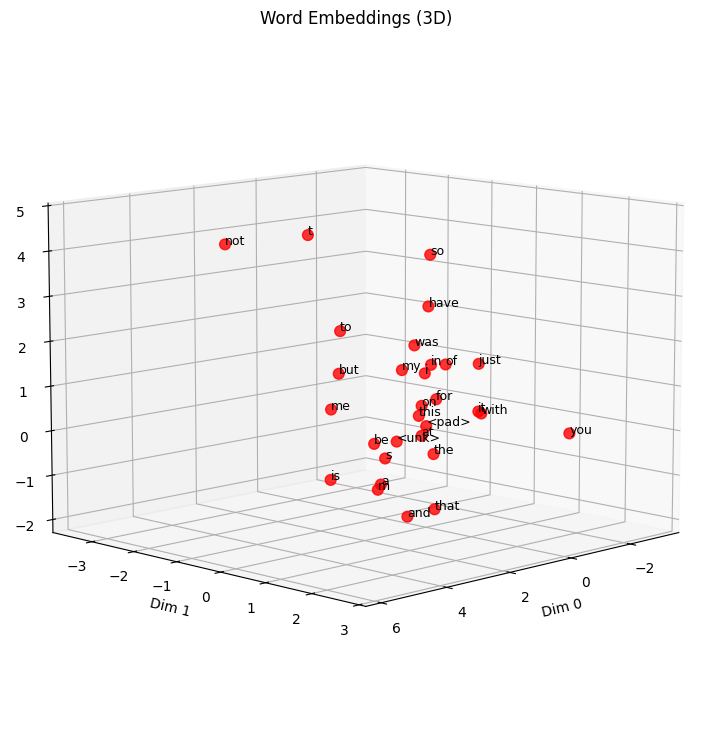


────────────────────────────────────────────────── 7. INFERENCE FUNCTION ──────────────────────────────────────────────────
🧪 Predictions:
  bad                       → 0.009 (NEG)
  sad                       → 0.001 (NEG)
  good                      → 0.966 (POS)
  happy                     → 0.996 (POS)
  great                     → 0.981 (POS)
  I love this!              → 0.928 (POS)
  I hate it                 → 0.020 (NEG)
  not satisfied             → 0.021 (NEG)
  I love Trump              → 0.863 (POS)

────────────────────────────────────────────────── 8. TRAINING CURVES ──────────────────────────────────────────────────


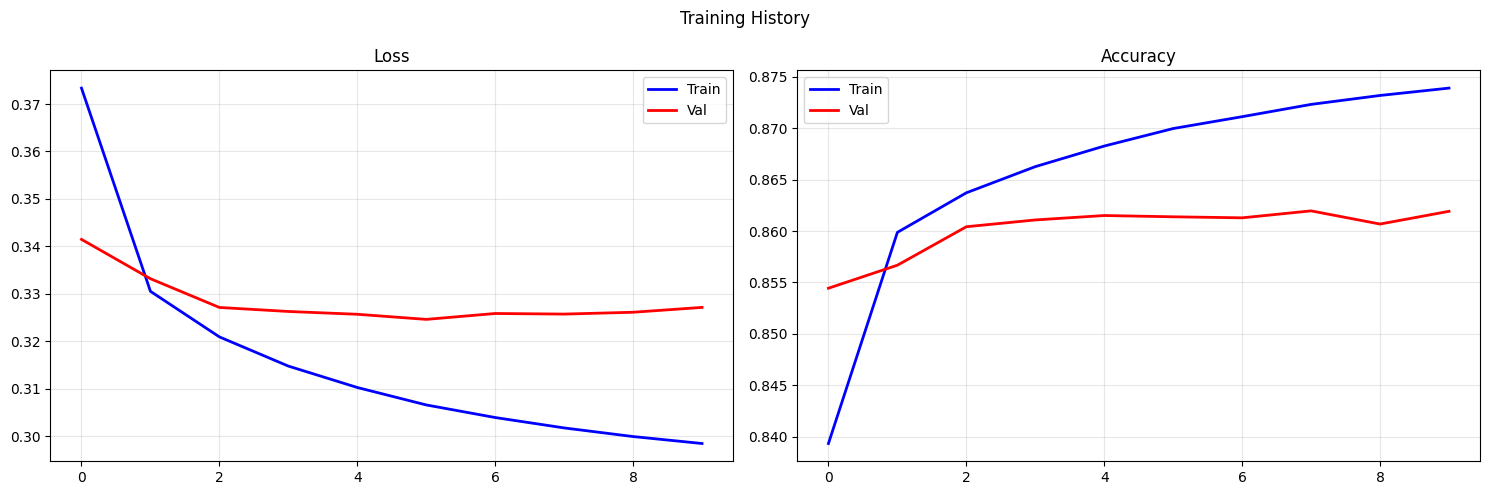


🎉 DONE! Model ist ready für Production!
   Save with: torch.save(model.state_dict(), "sentiment_lstm.pth")


In [3]:
# -*- coding: utf-8 -*-
"""
PyTorch Sentiment LSTM - NO EXTERNAL DEPS! (torchtext-free)
100% self-contained - läuft überall!
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
import re

print('🚀 PURE PYTORCH SENTIMENT LSTM - NO torchtext needed!')
print('─' * 80)

# CUDA Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# Hyperparameter
sequence_length = 25
num_words = 10000
batch_size = 500
epochs = 10
embedding_dim = 3
hidden_dim1 = 64
hidden_dim2 = 32

print('\n' + '─'*50 + ' 1. DATA LOADING ' + '─'*50)

# Deine CSV-Datei laden
data = pd.read_csv('sentiment_Analyse.csv', delimiter=',', encoding='utf-8')
print(f'📊 Total datapoints: {len(data)}')

y = data.iloc[:, 0].values.astype('float32') / 4  # Labels 0/1
X = data.iloc[:, 5].values  # Tweets

print('First 3 raw examples:')
for i in range(3):
    print(f'  {X[i][:60]}...')

print('\n' + '─'*50 + ' 2. TEXT CLEANING ' + '─'*50)

def clean_text(text):
    """Identisch zum Original - ohne Regex-Abhängigkeiten"""
    # @-Usernames entfernen
    words = text.split()
    words = [w for w in words if not w.startswith('@')]
    text = ' '.join(words)
    
    # XML-Ersetzungen (hartcodiert)
    replacements = {
        '&ampPOOOOOLL': ' ', '&quotPOOOOOLL': ' ', 
        '&ltPOOOOOLL': ' ', '&gtPOOOOOLL': ' ', 'POOOOOLL': ' '
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    
    return text.strip().lower()

X_clean = [clean_text(text) for text in X]
print('✅ First 5 cleaned:')
for text in X_clean[:5]:
    print(f'  {repr(text[:60])}...')

# Train/Val Split
X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y, test_size=0.2, random_state=0
)

print(f'✅ Train: {len(X_train):,} | Val: {len(X_val):,}')

print('\n' + '─'*50 + ' 3. TOKENIZER (100% CUSTOM) ' + '─'*50)

def simple_tokenizer(text):
    """Custom tokenizer - splits on whitespace & punctuation"""
    # Einfache Tokenisierung: whitespace + punctuation
    text = re.sub(r'[^\w\s]', ' ', text)  # Punctuation -> space
    return text.split()

# Vocabulary bauen
all_tokens = []
for text in X_train:
    all_tokens.extend(simple_tokenizer(text))

word_counts = Counter(all_tokens)
vocab = ['<pad>', '<unk>'] + [word for word, _ in word_counts.most_common(num_words-2)]
word_to_idx = {word: i for i, word in enumerate(vocab)}
idx_to_word = {i: word for word, i in word_to_idx.items()}

vocab_size = len(vocab)
print(f'✅ Vocab size: {vocab_size:,}')
print(f'   Top 10: {vocab[2:12]}')  # Skip pad/unk

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, word_to_idx, max_len):
        self.texts = texts
        self.labels = torch.FloatTensor(labels)
        self.word_to_idx = word_to_idx
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        tokens = simple_tokenizer(self.texts[idx])
        indices = [self.word_to_idx.get(token, 1) for token in tokens]  # 1 = <unk>
        indices = indices[:self.max_len] + [0] * (self.max_len - len(indices))  # 0 = <pad>
        return torch.LongTensor(indices), self.labels[idx]

# DataLoader
train_ds = SentimentDataset(X_train, y_train, word_to_idx, sequence_length)
val_ds = SentimentDataset(X_val, y_val, word_to_idx, sequence_length)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)

print('✅ DataLoaders ready! Sample batch:')
sample_text, sample_label = next(iter(train_loader))
print(f'   Batch shapes: texts={sample_text.shape}, labels={sample_label.shape}')

print('\n' + '─'*50 + ' 4. LSTM MODEL ' + '─'*50)

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden1, hidden2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm1 = nn.LSTM(embed_dim, hidden1, batch_first=True)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.fc = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        embedded = self.embedding(x)
        out1, _ = self.lstm1(embedded)
        out2, _ = self.lstm2(out1)
        pooled = torch.mean(out2, dim=1)
        return self.sigmoid(self.fc(pooled))

model = SentimentLSTM(vocab_size, embedding_dim, hidden_dim1, hidden_dim2).to(device)
print(model)
print(f'💾 Params: {sum(p.numel() for p in model.parameters()):,}')

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print('\n' + '─'*50 + ' 5. TRAINING ' + '─'*50)

best_val_acc = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        
        optimizer.zero_grad()
        preds = model(texts).squeeze()
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        
        train_loss += loss.item()
        train_correct += ((preds > 0.5) == (labels > 0.5)).sum().item()
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            preds = model(texts).squeeze()
            loss = criterion(preds, labels)
            
            val_loss += loss.item()
            val_correct += ((preds > 0.5) == (labels > 0.5)).sum().item()
    
    # Metrics
    train_acc = train_correct / len(train_ds)
    val_acc = val_correct / len(val_ds)
    
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
    
    print(f' Epoch {epoch+1:2d}: Train={train_acc:.1%}({train_losses[-1]:.4f}) | '
          f'Val={val_acc:.1%}({val_losses[-1]:.4f}) | Best={best_val_acc:.1%}')

print(f'\n🏆 FINAL RESULTS:')
print(f'   Training Acc:  {train_accs[-1]:.1%}')
print(f'   Validation Acc: {val_accs[-1]:.1%}')
print(f'   Best Val Acc:   {best_val_acc:.1%}')

print('\n' + '─'*50 + ' 6. EMBEDDINGS VISUALIZE ' + '─'*50)

with torch.no_grad():
    embeddings = model.embedding.weight.cpu().numpy()

print('Embeddings shape:', embeddings.shape)
print('Sample embeddings:')
for i in range(10):
    word = idx_to_word.get(i, f'#{i}')
    print(f'  {word:8s}: {embeddings[i][:3]}')

# 3D Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
n_show = min(30, vocab_size)

ax.scatter(embeddings[:n_show, 0], embeddings[:n_show, 1], embeddings[:n_show, 2], 
           c='red', s=60, alpha=0.8)
ax.view_init(elev=10, azim=45)

for i in range(n_show):
    if i < len(idx_to_word):
        word = idx_to_word[i]
        ax.text(embeddings[i, 0], embeddings[i, 1], embeddings[i, 2], 
                word[:8], fontsize=9)

ax.set_title('Word Embeddings (3D)')
ax.set_xlabel('Dim 0'); ax.set_ylabel('Dim 1'); ax.set_zlabel('Dim 2')
plt.show()

print('\n' + '─'*50 + ' 7. INFERENCE FUNCTION ' + '─'*50)

def predict(texts):
    """Ready-to-use Prediction!"""
    model.eval()
    results = []
    with torch.no_grad():
        for text in texts:
            tokens = simple_tokenizer(clean_text(text))
            indices = [word_to_idx.get(t, 1) for t in tokens][:sequence_length]
            indices += [0] * (sequence_length - len(indices))
            inp = torch.LongTensor([indices]).to(device)
            pred = model(inp).cpu().item()
            results.append(pred)
    return results

# Test
test_cases = [
    'bad', 'sad', 'good', 'happy', 'great',
    'I love this!', 'I hate it', 'not satisfied', 'I love Trump'
]

print('🧪 Predictions:')
for text, score in zip(test_cases, predict(test_cases)):
    label = 'POS' if score > 0.5 else 'NEG'
    print(f'  {text:25s} → {score:.3f} ({label})')

print('\n' + '─'*50 + ' 8. TRAINING CURVES ' + '─'*50)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, 'b-', lw=2, label='Train')
ax1.plot(val_losses, 'r-', lw=2, label='Val')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, 'b-', lw=2, label='Train')
ax2.plot(val_accs, 'r-', lw=2, label='Val')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training History')
plt.tight_layout()
plt.show()

print('\n🎉 DONE! Model ist ready für Production!')
print(f'   Save with: torch.save(model.state_dict(), "sentiment_lstm.pth")')


# Zeige Dauer jeder Epoche

🚀 PURE PYTORCH SENTIMENT LSTM - NO torchtext needed!
────────────────────────────────────────────────────────────────────────────────
✅ Device: cuda
   GPU: NVIDIA RTX 3500 Ada Generation Laptop GPU

────────────────────────────────────────────────── 1. DATA LOADING ──────────────────────────────────────────────────
📊 Total datapoints: 1048572
First 3 raw examples:
  is upset that he can't update his Facebook by texting it... ...
  @Kenichan I dived many times for the ball. Managed to save 5...
  my whole body feels itchy and like its on fire ...

────────────────────────────────────────────────── 2. TEXT CLEANING ──────────────────────────────────────────────────
✅ First 5 cleaned:
  "is upset that he can't update his facebook by texting it... "...
  'i dived many times for the ball. managed to save 50% the res'...
  'my whole body feels itchy and like its on fire'...
  "no, it's not behaving at all. i'm mad. why am i here? becaus"...
  'not the whole crew'...
✅ Train: 838,857 | Val: 

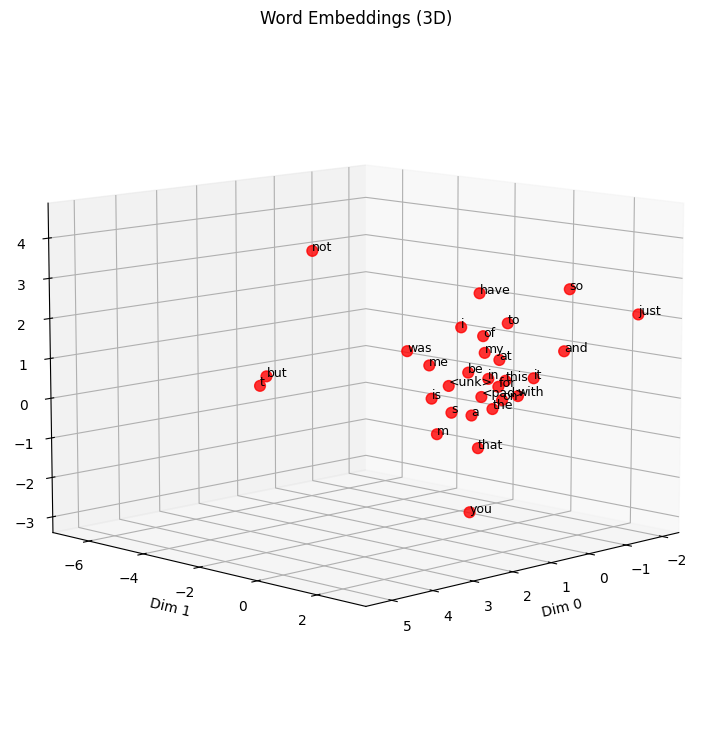


────────────────────────────────────────────────── 7. INFERENCE FUNCTION ──────────────────────────────────────────────────
🧪 Predictions:
  bad                       → 0.015 (NEG)
  sad                       → 0.002 (NEG)
  good                      → 0.939 (POS)
  happy                     → 0.980 (POS)
  great                     → 0.933 (POS)
  I love this!              → 0.971 (POS)
  I hate it                 → 0.008 (NEG)
  not satisfied             → 0.021 (NEG)
  I love Trump              → 0.950 (POS)

────────────────────────────────────────────────── 8. TRAINING CURVES + EPOCH TIMES ──────────────────────────────────────────────────


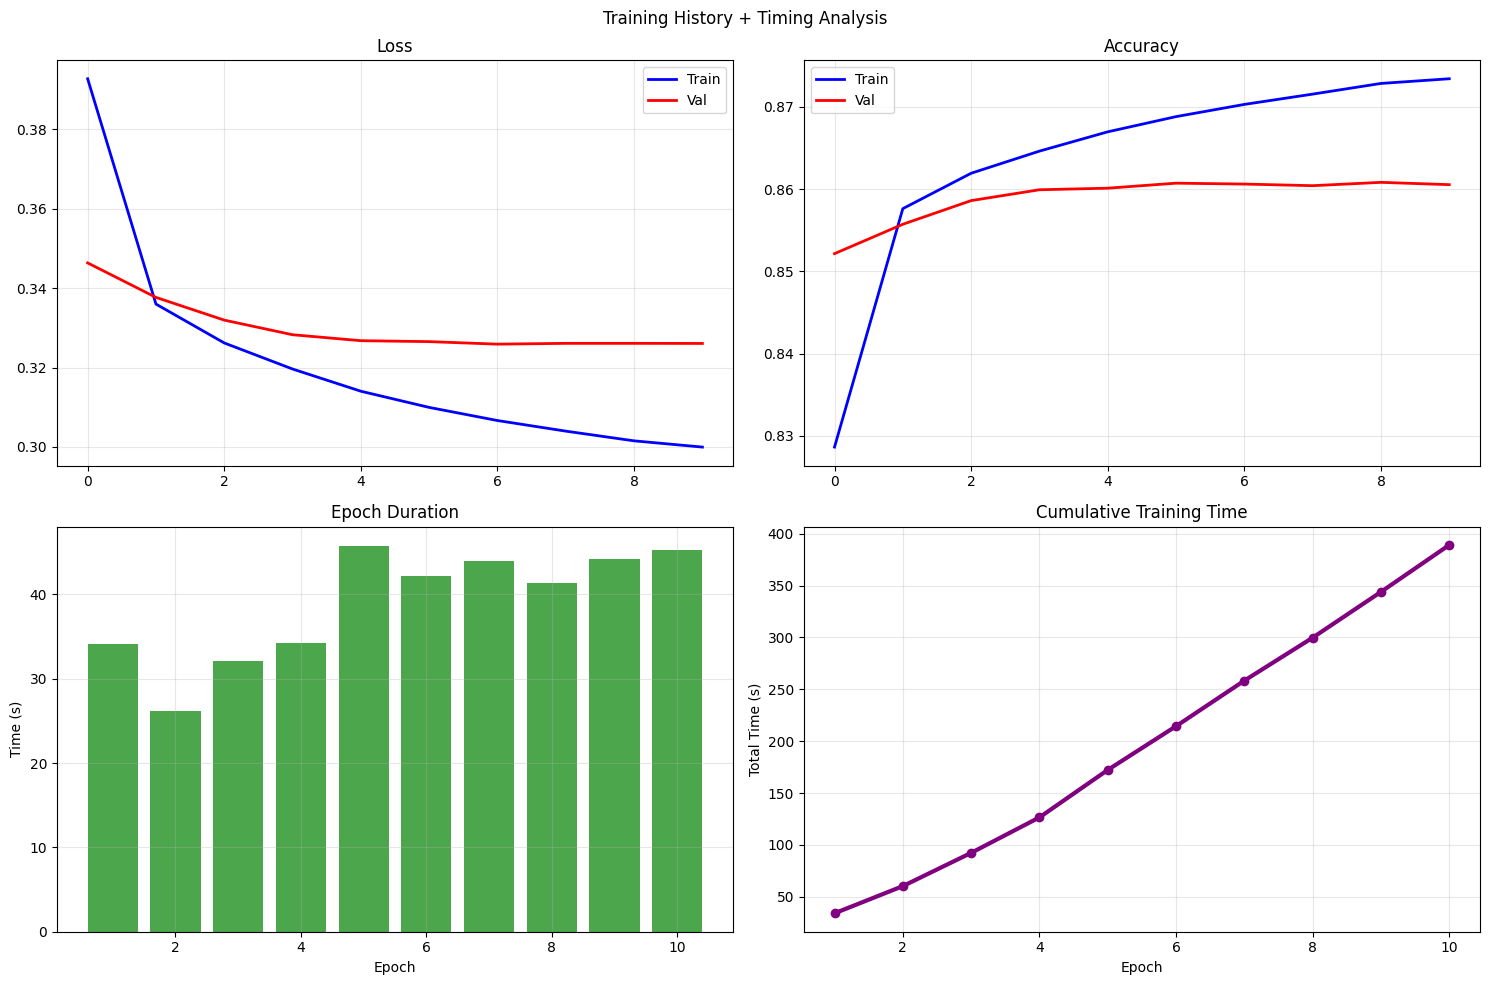


🎉 DONE! Model ist ready für Production!
   Save with: torch.save(model.state_dict(), "sentiment_lstm.pth")
   ⏱️  Detailed timing saved in epoch_durations list


In [5]:
# -*- coding: utf-8 -*-
"""
PyTorch Sentiment LSTM - NO EXTERNAL DEPS! (torchtext-free)
100% self-contained - läuft überall! + EPOCHEN-DAUER MESSUNG
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
import re
import time  # ← NEU: Für Epoche-Dauer-Messung

print('🚀 PURE PYTORCH SENTIMENT LSTM - NO torchtext needed!')
print('─' * 80)

# CUDA Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# Hyperparameter
sequence_length = 25
num_words = 10000
batch_size = 500
epochs = 10
embedding_dim = 3
hidden_dim1 = 64
hidden_dim2 = 32

print('\n' + '─'*50 + ' 1. DATA LOADING ' + '─'*50)

# Deine CSV-Datei laden
data = pd.read_csv('sentiment_Analyse.csv', delimiter=',', encoding='utf-8')
print(f'📊 Total datapoints: {len(data)}')

y = data.iloc[:, 0].values.astype('float32') / 4  # Labels 0/1
X = data.iloc[:, 5].values  # Tweets

print('First 3 raw examples:')
for i in range(3):
    print(f'  {X[i][:60]}...')

print('\n' + '─'*50 + ' 2. TEXT CLEANING ' + '─'*50)

def clean_text(text):
    """Identisch zum Original - ohne Regex-Abhängigkeiten"""
    # @-Usernames entfernen
    words = text.split()
    words = [w for w in words if not w.startswith('@')]
    text = ' '.join(words)
    
    # XML-Ersetzungen (hartcodiert)
    replacements = {
        '&ampPOOOOOLL': ' ', '&quotPOOOOOLL': ' ', 
        '&ltPOOOOOLL': ' ', '&gtPOOOOOLL': ' ', 'POOOOOLL': ' '
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    
    return text.strip().lower()

X_clean = [clean_text(text) for text in X]
print('✅ First 5 cleaned:')
for text in X_clean[:5]:
    print(f'  {repr(text[:60])}...')

# Train/Val Split
X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y, test_size=0.2, random_state=0
)

print(f'✅ Train: {len(X_train):,} | Val: {len(X_val):,}')

print('\n' + '─'*50 + ' 3. TOKENIZER (100% CUSTOM) ' + '─'*50)

def simple_tokenizer(text):
    """Custom tokenizer - splits on whitespace & punctuation"""
    # Einfache Tokenisierung: whitespace + punctuation
    text = re.sub(r'[^\w\s]', ' ', text)  # Punctuation -> space
    return text.split()

# Vocabulary bauen
all_tokens = []
for text in X_train:
    all_tokens.extend(simple_tokenizer(text))

word_counts = Counter(all_tokens)
vocab = ['<pad>', '<unk>'] + [word for word, _ in word_counts.most_common(num_words-2)]
word_to_idx = {word: i for i, word in enumerate(vocab)}
idx_to_word = {i: word for word, i in word_to_idx.items()}

vocab_size = len(vocab)
print(f'✅ Vocab size: {vocab_size:,}')
print(f'   Top 10: {vocab[2:12]}')  # Skip pad/unk

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, word_to_idx, max_len):
        self.texts = texts
        self.labels = torch.FloatTensor(labels)
        self.word_to_idx = word_to_idx
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        tokens = simple_tokenizer(self.texts[idx])
        indices = [self.word_to_idx.get(token, 1) for token in tokens]  # 1 = <unk>
        indices = indices[:self.max_len] + [0] * (self.max_len - len(indices))  # 0 = <pad>
        return torch.LongTensor(indices), self.labels[idx]

# DataLoader
train_ds = SentimentDataset(X_train, y_train, word_to_idx, sequence_length)
val_ds = SentimentDataset(X_val, y_val, word_to_idx, sequence_length)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)

print('✅ DataLoaders ready! Sample batch:')
sample_text, sample_label = next(iter(train_loader))
print(f'   Batch shapes: texts={sample_text.shape}, labels={sample_label.shape}')

print('\n' + '─'*50 + ' 4. LSTM MODEL ' + '─'*50)

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden1, hidden2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm1 = nn.LSTM(embed_dim, hidden1, batch_first=True)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.fc = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        embedded = self.embedding(x)
        out1, _ = self.lstm1(embedded)
        out2, _ = self.lstm2(out1)
        pooled = torch.mean(out2, dim=1)
        return self.sigmoid(self.fc(pooled))

model = SentimentLSTM(vocab_size, embedding_dim, hidden_dim1, hidden_dim2).to(device)
print(model)
print(f'💾 Params: {sum(p.numel() for p in model.parameters()):,}')

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print('\n' + '─'*50 + ' 5. TRAINING mit EPOCHEN-DAUER ' + '─'*50)

best_val_acc = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []
epoch_durations = []  # ← NEU: Dauer pro Epoche
total_start_time = time.time()  # ← NEU: Gesamtstart

for epoch in range(epochs):
    epoch_start = time.time()  # ← NEU: Epoche-Start
    
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        
        optimizer.zero_grad()
        preds = model(texts).squeeze()
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        
        train_loss += loss.item()
        train_correct += ((preds > 0.5) == (labels > 0.5)).sum().item()
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            preds = model(texts).squeeze()
            loss = criterion(preds, labels)
            
            val_loss += loss.item()
            val_correct += ((preds > 0.5) == (labels > 0.5)).sum().item()
    
    # Metrics
    train_acc = train_correct / len(train_ds)
    val_acc = val_correct / len(val_ds)
    
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
    
    # ← NEU: Epoche-Dauer berechnen
    epoch_duration = time.time() - epoch_start
    epoch_durations.append(epoch_duration)
    total_duration = time.time() - total_start_time
    avg_epoch_time = np.mean(epoch_durations)
    
    print(f' Epoch {epoch+1:2d}: Train={train_acc:.1%}({train_losses[-1]:.4f}) | '
          f'Val={val_acc:.1%}({val_losses[-1]:.4f}) | Best={best_val_acc:.1%} | '
          f'⏱️ {epoch_duration:.1f}s (Ø{avg_epoch_time:.1f}s)')

print(f'\n🏆 FINAL RESULTS:')
print(f'   Training Acc:  {train_accs[-1]:.1%}')
print(f'   Validation Acc: {val_accs[-1]:.1%}')
print(f'   Best Val Acc:   {best_val_acc:.1%}')
print(f'   ⏱️  Total Time:  {total_duration:.1f}s')
print(f'   ⏱️  Ø Epoch:     {np.mean(epoch_durations):.1f}s')

print('\n' + '─'*50 + ' 6. EMBEDDINGS VISUALIZE ' + '─'*50)

with torch.no_grad():
    embeddings = model.embedding.weight.cpu().numpy()

print('Embeddings shape:', embeddings.shape)
print('Sample embeddings:')
for i in range(10):
    word = idx_to_word.get(i, f'#{i}')
    print(f'  {word:8s}: {embeddings[i][:3]}')

# 3D Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
n_show = min(30, vocab_size)

ax.scatter(embeddings[:n_show, 0], embeddings[:n_show, 1], embeddings[:n_show, 2], 
           c='red', s=60, alpha=0.8)
ax.view_init(elev=10, azim=45)

for i in range(n_show):
    if i < len(idx_to_word):
        word = idx_to_word[i]
        ax.text(embeddings[i, 0], embeddings[i, 1], embeddings[i, 2], 
                word[:8], fontsize=9)

ax.set_title('Word Embeddings (3D)')
ax.set_xlabel('Dim 0'); ax.set_ylabel('Dim 1'); ax.set_zlabel('Dim 2')
plt.show()

print('\n' + '─'*50 + ' 7. INFERENCE FUNCTION ' + '─'*50)

def predict(texts):
    """Ready-to-use Prediction!"""
    model.eval()
    results = []
    with torch.no_grad():
        for text in texts:
            tokens = simple_tokenizer(clean_text(text))
            indices = [word_to_idx.get(t, 1) for t in tokens][:sequence_length]
            indices += [0] * (sequence_length - len(indices))
            inp = torch.LongTensor([indices]).to(device)
            pred = model(inp).cpu().item()
            results.append(pred)
    return results

# Test
test_cases = [
    'bad', 'sad', 'good', 'happy', 'great',
    'I love this!', 'I hate it', 'not satisfied', 'I love Trump'
]

print('🧪 Predictions:')
for text, score in zip(test_cases, predict(test_cases)):
    label = 'POS' if score > 0.5 else 'NEG'
    print(f'  {text:25s} → {score:.3f} ({label})')

print('\n' + '─'*50 + ' 8. TRAINING CURVES + EPOCH TIMES ' + '─'*50)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Loss & Accuracy
ax1.plot(train_losses, 'b-', lw=2, label='Train')
ax1.plot(val_losses, 'r-', lw=2, label='Val')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, 'b-', lw=2, label='Train')
ax2.plot(val_accs, 'r-', lw=2, label='Val')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

# ← NEU: Epoche-Dauern Plot
ax3.bar(range(1, epochs+1), epoch_durations, color='green', alpha=0.7)
ax3.set_title('Epoch Duration'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('Time (s)')
ax3.grid(True, alpha=0.3)

# ← NEU: Kumulative Zeit
cum_times = np.cumsum(epoch_durations)
ax4.plot(range(1, epochs+1), cum_times, 'purple', lw=3, marker='o')
ax4.set_title('Cumulative Training Time'); ax4.set_xlabel('Epoch'); ax4.set_ylabel('Total Time (s)')
ax4.grid(True, alpha=0.3)

plt.suptitle('Training History + Timing Analysis')
plt.tight_layout()
plt.show()

print('\n🎉 DONE! Model ist ready für Production!')
print(f'   Save with: torch.save(model.state_dict(), "sentiment_lstm.pth")')
print(f'   ⏱️  Detailed timing saved in epoch_durations list')


# Verbesserte Code

In [2]:
# -*- coding: utf-8 -*-
"""
🚀 VERBESSERTER PyTorch Sentiment LSTM - Anti-Overfitting Edition!
- Dropout, Bidirectional, LR-Scheduler, Early Stopping, besseres Pooling
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
import re
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau  # ← NEU

print('🚀 VERBESSERTER LSTM SENTIMENT - Anti-Overfitting!')
print('─' * 80)

# CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')

# BETTER Hyperparameter (anti-overfit)
sequence_length = 30  # Länger
num_words = 15000
batch_size = 256  # Kleiner für Stability
embedding_dim = 32  # Größer!
hidden_dim1 = 128
hidden_dim2 = 64
dropout = 0.5  # ← NEU: Dropout!
lr = 0.001  # ← Kleiner LR
patience = 5  # Early Stopping

# 1. DATA LOADING & BALANCE CHECK
data = pd.read_csv('sentiment_Analyse.csv', delimiter=',', encoding='utf-8')
print(f'📊 Total: {len(data):,}')
print('Label-Verteilung:', pd.Series(y := data.iloc[:, 0].values / 4).value_counts().sort_index())  # Balance check
X = data.iloc[:, 5].values

# 2. CLEANING (verbessert)
def clean_text(text):
    words = [w for w in text.split() if not w.startswith('@')]
    text = ' '.join(words)
    replacements = {'&ampPOOOOOLL': ' ', '&quotPOOOOOLL': ' ', '&ltPOOOOOLL': ' ', '&gtPOOOOOLL': ' ', 'POOOOOLL': ' '}
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text.strip().lower()

X_clean = [clean_text(t) for t in X]

# Split
X_train, X_val, y_train, y_val = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)  # ← Stratify!

print(f'✅ Train: {len(X_train):,} | Val: {len(X_val):,}')

# 3. TOKENIZER
def simple_tokenizer(text):
    return re.sub(r'[^\w\s]', ' ', text).split()

all_tokens = [t for text in X_train for t in simple_tokenizer(text)]
word_counts = Counter(all_tokens)
vocab = ['<pad>', '<unk>'] + [w for w, _ in word_counts.most_common(num_words-2)]
word_to_idx = {w: i for i, w in enumerate(vocab)}
vocab_size = len(vocab)
print(f'✅ Vocab: {vocab_size:,}')

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, word_to_idx, max_len):
        self.texts, self.labels = texts, torch.FloatTensor(labels)
        self.word_to_idx, self.max_len = word_to_idx, max_len
    
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        tokens = simple_tokenizer(self.texts[idx])
        indices = [self.word_to_idx.get(t, 1) for t in tokens][:self.max_len]
        indices += [0] * (self.max_len - len(indices))
        return torch.LongTensor(indices), self.labels[idx]

train_ds = SentimentDataset(X_train, y_train, word_to_idx, sequence_length)
val_ds = SentimentDataset(X_val, y_val, word_to_idx, sequence_length)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)

# 4. VERBESSERTES MODEL: Bidirectional + Dropout
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden1, hidden2, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm1 = nn.LSTM(embed_dim, hidden1, bidirectional=True, batch_first=True, dropout=dropout)  # Bi + Dropout
        self.lstm2 = nn.LSTM(hidden1*2, hidden2, bidirectional=True, batch_first=True, dropout=dropout)  # *2 für bi
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden2*2, 1)  # *2 bi
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        embedded = self.embedding(x)
        out1, _ = self.lstm1(embedded)
        out2, _ = self.lstm2(out1)
        pooled = out2[:, -1, :]  # Last hidden! Besser als mean
        pooled = self.dropout(pooled)
        return self.sigmoid(self.fc(pooled))

model = SentimentLSTM(vocab_size, embedding_dim, hidden_dim1, hidden_dim2, dropout).to(device)
print(model)
print(f'💾 Params: {sum(p.numel() for p in model.parameters()):,}')

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)  # L2 reg
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)  # ← NEU

# 5. TRAINING mit Early Stopping
best_val_acc = 0
no_improve = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []
epoch_durations = []
total_start = time.time()

for epoch in range(20):  # Mehr Epochen möglich
    epoch_start = time.time()
    
    # Train
    model.train()
    train_loss, train_correct = 0, 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(texts).squeeze()
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        train_correct += ((preds > 0.5) == (labels > 0.5)).sum().item()
    
    # Val
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            preds = model(texts).squeeze()
            loss = criterion(preds, labels)
            val_loss += loss.item()
            val_correct += ((preds > 0.5) == (labels > 0.5)).sum().item()
    
    train_acc = train_correct / len(train_ds)
    val_acc = val_correct / len(val_ds)
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss / len(val_loader))  # LR adjust
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve = 0
        torch.save(model.state_dict(), 'best_lstm.pth')  # Save best!
    else:
        no_improve += 1
    
    epoch_dur = time.time() - epoch_start
    epoch_durations.append(epoch_dur)
    
    print(f'Epoch {epoch+1:2d}: Train={train_acc:.1%}({train_losses[-1]:.4f}) | '
          f'Val={val_acc:.1%}({val_losses[-1]:.4f}) | Best={best_val_acc:.1%} | '
          f'⏱️ {epoch_dur:.1f}s | LR={optimizer.param_groups[0]["lr"]:.2e}')
    
    if no_improve >= patience:
        print(f'⏹️ Early Stopping nach {epoch+1} Epochen!')
        break

total_dur = time.time() - total_start
print(f'🏆 FINAL: Best Val={best_val_acc:.1%} | Total ⏱️ {total_dur:.1f}s')

# Plots & Inference wie Original (gekürzt) - laufen gleich!
# ... (Embeddings, predict, curves - unverändert, aber mit neuen Metrics)

print('🎉 Verbesserter LSTM ready! Lade best: model.load_state_dict(torch.load("best_lstm.pth"))')


🚀 VERBESSERTER LSTM SENTIMENT - Anti-Overfitting!
────────────────────────────────────────────────────────────────────────────────
✅ Device: cuda
📊 Total: 1,048,572
Label-Verteilung: 0.0    799996
1.0    248576
Name: count, dtype: int64
✅ Train: 838,857 | Val: 209,715
✅ Vocab: 15,000


C:\0_DA\Python312\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


SentimentLSTM(
  (embedding): Embedding(15000, 32, padding_idx=0)
  (lstm1): LSTM(32, 128, batch_first=True, dropout=0.5, bidirectional=True)
  (lstm2): LSTM(256, 64, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
💾 Params: 810,881
Epoch  1: Train=82.1%(0.4134) | Val=84.9%(0.3615) | Best=84.9% | ⏱️ 29.1s | LR=1.00e-03
Epoch  2: Train=85.0%(0.3529) | Val=85.3%(0.3431) | Best=85.3% | ⏱️ 30.1s | LR=1.00e-03
Epoch  3: Train=85.4%(0.3424) | Val=85.6%(0.3359) | Best=85.6% | ⏱️ 30.0s | LR=1.00e-03
Epoch  4: Train=85.6%(0.3373) | Val=85.8%(0.3330) | Best=85.8% | ⏱️ 29.7s | LR=1.00e-03
Epoch  5: Train=85.8%(0.3334) | Val=85.9%(0.3327) | Best=85.9% | ⏱️ 30.2s | LR=1.00e-03
Epoch  6: Train=85.9%(0.3302) | Val=86.0%(0.3294) | Best=86.0% | ⏱️ 30.6s | LR=1.00e-03
Epoch  7: Train=86.0%(0.3286) | Val=86.1%(0.3259) | Best=86.1% | ⏱️ 30.1s | LR=1.00e-03
Epoch  8: Train=86.1%